In [39]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
# import torchvision.transforms.functional as TF
import torch.nn.functional as F

from PIL import Image
from pathlib import Path

import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt

# ML model to estimate the parameter values

* G_align
* G_density
* G_curve
* G_conn
* L_align
* L_density
* L_conn
* L_curve
* spline_length
* spline_num
* wave_amplitude_px
* wave_wavelength_px (can be None)
* L_wave_freq

## Input: pickle files

* 256x256 image np.arrays, normalized [0,1]
* metadata 


* Run filtration??

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, img_path):
        self.pkl_paths = list(Path(img_path).glob("*pkl"))

    def __len(self):
        return len(self.pkl_path)
    
    def __getitem__(self, idx):
        # Get path
        pkl_path = self.pkl_paths[idx]

        # Load file
        with open('pickle_path', 'rb') as file:
            data = pickle.load(file)

        img = torch.tensor(data['img']) # Is a np.array
        density = torch.tensor(data['density'])
        vector = torch.tensor(data['vector'])

        meta_dict = data['meta'] # Dict of metadata
        
        return img, meta_dict, str(img_path)


def load_metadata(meta_dict):
    G_align = meta_dict.get("G_align")
    G_density = meta_dict.get("G_density")
    G_curve = meta_dict.get("G_curve")
    G_conn = meta_dict.get("G_conn")

    L_align = meta_dict.get("L_align")
    L_density = meta_dict.get("L_density")
    L_conn = meta_dict.get("L_conn")
    L_curve = meta_dict.get("L_curve")

    spline_length = meta_dict.get("spline_length")
    spline_num = meta_dict.get("spline_num")

    wave_amplitude_px = meta_dict.get("wave_amplitude_px")
    wave_wavelength_px = meta_dict.get("wave_wavelength_px")  # Can be None
    L_wave_freq = meta_dict.get("L_wave_freq")

    return (
        G_align,
        G_density,
        G_curve,
        G_conn,
        L_align,
        L_density,
        L_conn,
        L_curve,
        spline_length,
        spline_num,
        wave_amplitude_px,
        wave_wavelength_px,
        L_wave_freq,
    )


In [ ]:
res = syn.generate_synthetic_shg(
    seed=10, G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=1000,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=0.5,
    show_plots=True,
    minimal=True,
)

In [ ]:
{
    'seed': ,
    'G_align': ,
    'G_density': ,
    'G_curve': ,
    'G_conn': ,
    'L_align': ,
    'L_density':,
    'L_conn': ,
    'L_curve': ,
    'spline_length': ,
    'spline_num': ,
    'wave_amplitude_px': ,
    'wave_wavelength_px': ,
    'L_wave_freq': ,
}

In [ ]:
class SyntheticCNN(nn.Module):
    def __init__(
        self, 
        n_channels=5, 
        n_filters=16
    ):
    super(SyntheticCNN, self).__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(n_channels, n_filters, padding=1),
        nn.GELU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(n_filters, n_filters*2, padding=1),
        nn.GELU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(n_filters*2, n_filters*4, padding=1),
        nn.GELU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    # self.fcl = nn.linear() #nn.Flatten()

    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(n_filters*4, n_filters*2, stride=2, padding=1, output_padding=1),
        nn.GELU(),
        nn.Conv




    )

class Decoder

In [44]:
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, num_filters):
        super(EncoderBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d((2, 2), stride=2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        skip_features = F.relu(self.conv2(x)) # We want this for the skip connection
        pool_out = self.pool(skip_features)   # This goes to the next encoder layer
        return skip_features, pool_out
    

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, num_filters, skip_channels):
        super(DecoderBlock, self).__init__()

        self.convT = nn.ConvTranspose2d(in_channels, num_filters, kernel_size=2, stride=2)
        self.conv1 = nn.Conv2d(num_filters + skip_channels, num_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size=3, padding=1)

    def forward(self, x, skip_features):
        x = self.convT(x)
        # Skip features
        if skip_features.shape[2:] != x.shape[2:]:
            skip_features = TF.resize(skip_features, size=x.shape[2:])
        
        # Concate skips
        x = torch.cat([x, skip_features], dim=1)

        # ReLU
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        return x


class UNET(nn.Module):
    def __init__(self, 
                 input_img_size=512,
                 num_filters=64, # for a 512 image
                 in_channels=1,  # n_channels, 3d will have more...
                 num_classes=1,   # grayscale images, numclasses=1
                 num_params=12):
        super(UNET, self).__init__()

        self.enc1 = EncoderBlock(in_channels, num_filters)
        self.enc2 = EncoderBlock(num_filters, num_filters*2)
        self.enc3 = EncoderBlock(num_filters*2, num_filters*4)
        self.enc4 = EncoderBlock(num_filters*4, num_filters*8)

        self.bottleneck_conv1 = nn.Conv2d(num_filters*8, num_filters*16, kernel_size=3, padding=1)
        self.bottleneck_conv2 = nn.Conv2d(num_filters*16, num_filters*16, kernel_size=3, padding=1)

        self.dec1 = DecoderBlock(num_filters*16, num_filters*8, num_filters*8) #input, skip, filters
        self.dec2 = DecoderBlock(num_filters*8, num_filters*4, num_filters*4)
        self.dec3 = DecoderBlock(num_filters*4, num_filters*2, num_filters*2)
        self.dec4 = DecoderBlock(num_filters*2, num_filters, num_filters)

        self.final_conv = nn.Conv2d(num_filters, num_classes, kernel_size=1) #Replace with the classifiers

        self.density_head = nn.Sequential(
            nn.Conv2d(num_filters, num_filters // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(num_filters // 2, 1, kernel_size=1),
            nn.Sigmoid() #[0,1]
        )

        self.vector_head = nn.Sequential(
            nn.Conv2d(num_filters, num_filters // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(num_filters // 2, 1, kernel_size=1),
            nn.Sigmoid() #[0,1], maybe tan
        )

        flat_size = (input_img_size // 16)**2 * (num_filters*16) #img_size * num_filters
        self.meta_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_params)
        )

    def forward(self, x):
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)

        b1 = self.bottleneck_conv1(p4)
        b2 = self.bottleneck_conv2(b1)

        meta = self.meta_head(b2)

        d1 = self.dec1(b2, s4)
        d2 = self.dec2(d1, s3)
        d3 = self.dec3(d2, s2)
        d4 = self.dec4(d3, s1)

        shg = self.final_conv(d4)
        density = self.density_head(d4)
        vector = self.vector_head(d4)

        return shg, meta, density, vector #self.final_conv(d4)


In [46]:
model = UNET(num_filters=64, in_channels=1)

x = torch.randn(2, 1, 512, 512)

shg, meta, density, vector = model(x)

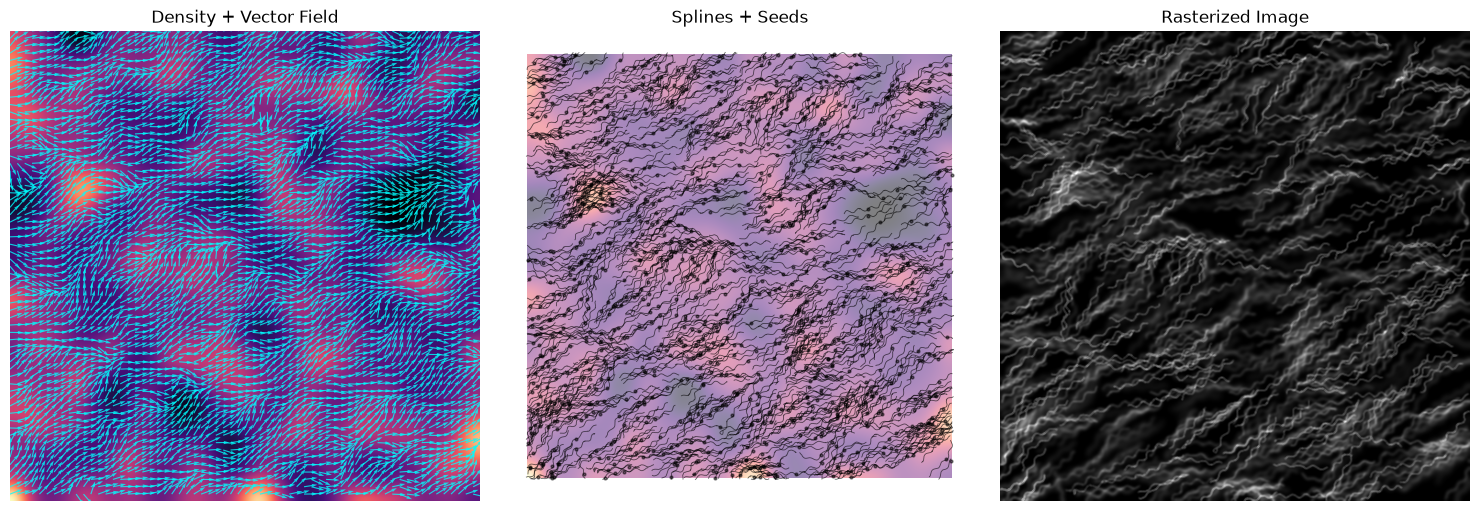

In [1]:
import random
from SyntheticGen import *

n_images = 10
seed = 10

random.seed(seed)

# for n in range(n_images):
#     G_align = round(random.uniform(0, 1), 2)
    


res = generate_synthetic_shg_3d(
    seed=seed, 
    G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=400,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=0.5,
    show_plots=True,
    minimal=True,
    depth=3,
    n_layers=10,
    focal_depth=1,
    depth_blur_scale=2,
    anisotropy=True,
    hotspots=False
)


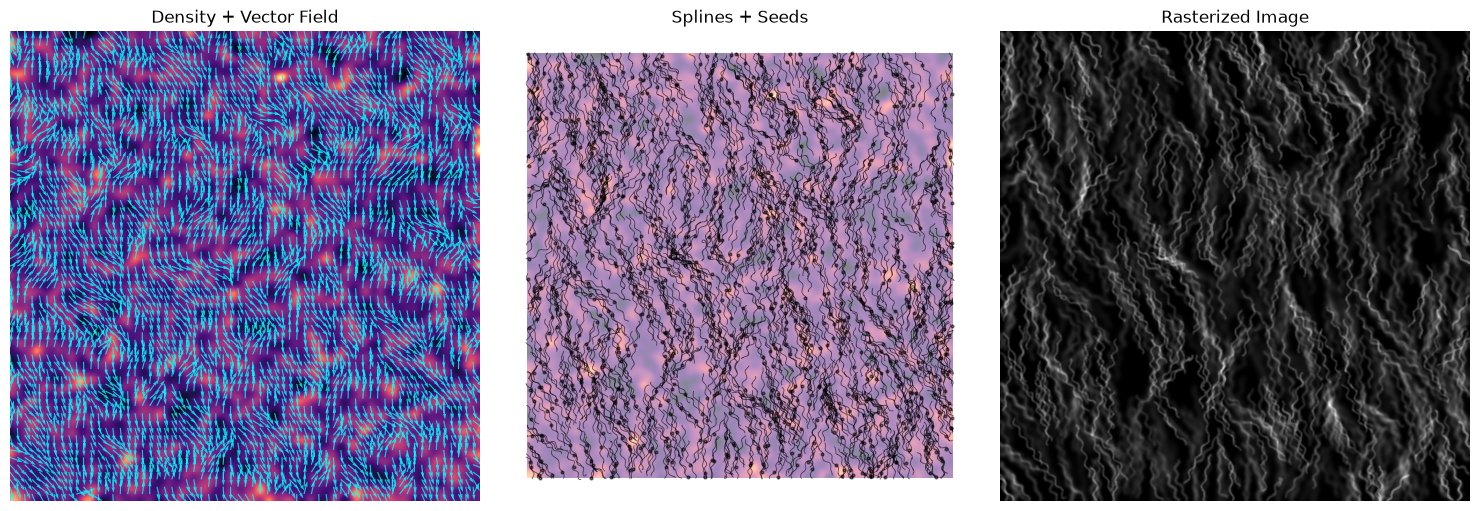

In [3]:
res = generate_synthetic_shg_3d(
    seed=seed, 
    G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=400,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=0.5,
    show_plots=True,
    minimal=True,
    depth=3,
    n_layers=10,
    focal_depth=1,
    depth_blur_scale=2,
    anisotropy=False,
    hotspots=False
)


In [3]:
theta #1024, 1024

array([[ 1.25925542,  1.25998594,  1.26141533, ...,  0.82809956,
         0.82332774,  0.82093148],
       [ 1.25790857,  1.25864678,  1.26009148, ...,  0.83120743,
         0.82645661,  0.82407088],
       [ 1.25527913,  1.25603286,  1.25750843, ...,  0.83741868,
         0.83270969,  0.83034491],
       ...,
       [ 1.45971456,  1.4616092 ,  1.46536471, ..., -0.43039477,
        -0.42508915, -0.42240624],
       [ 1.45946166,  1.46136634,  1.46514192, ..., -0.42187257,
        -0.41653111, -0.41382993],
       [ 1.45934497,  1.46125474,  1.4650405 , ..., -0.4176029 ,
        -0.41224353, -0.40953321]], shape=(1024, 1024))

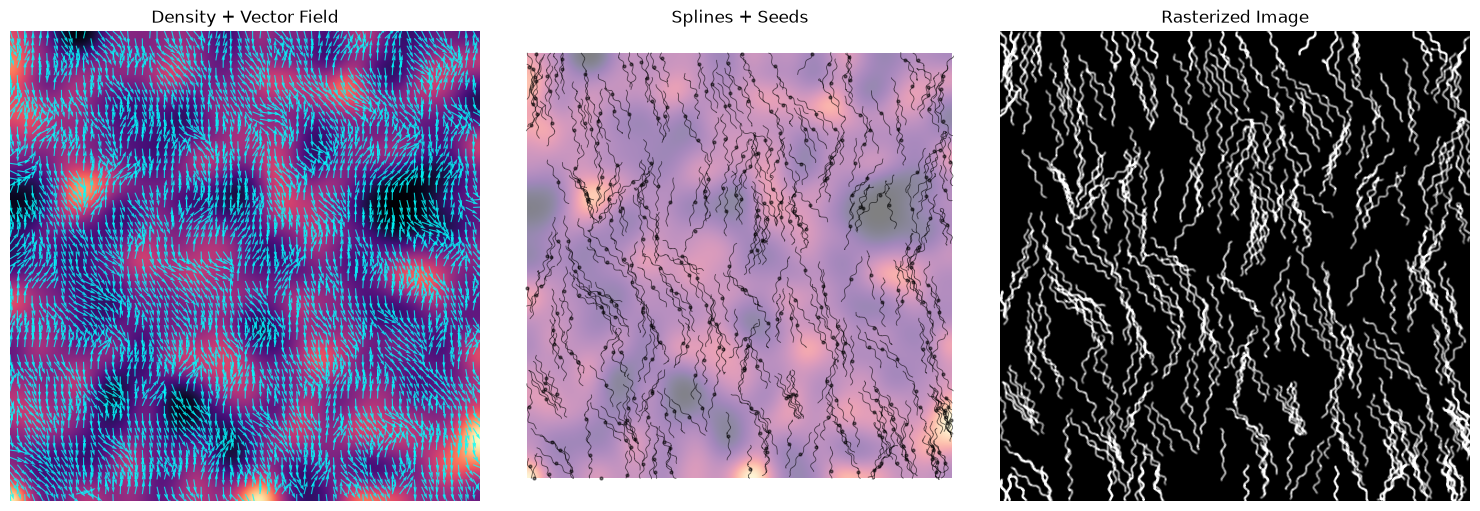

In [ ]:
res = generate_synthetic_shg(
    seed=seed, 
    G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=400,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=0.5,
    show_plots=True,
    minimal=True,

)

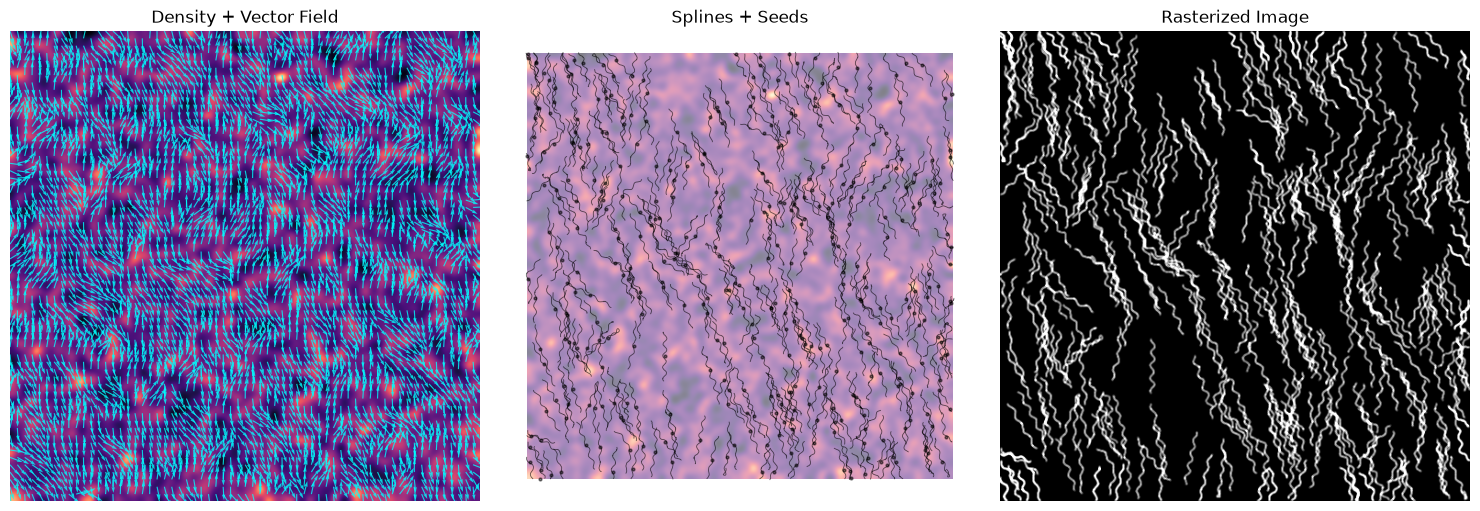

In [1]:
import random
from SyntheticGen import *
seed = 10

res = generate_synthetic_shg(
    seed=seed, 
    G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=400,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=0.5,
    show_plots=True,
    minimal=True,
    base_noise=3.0
)

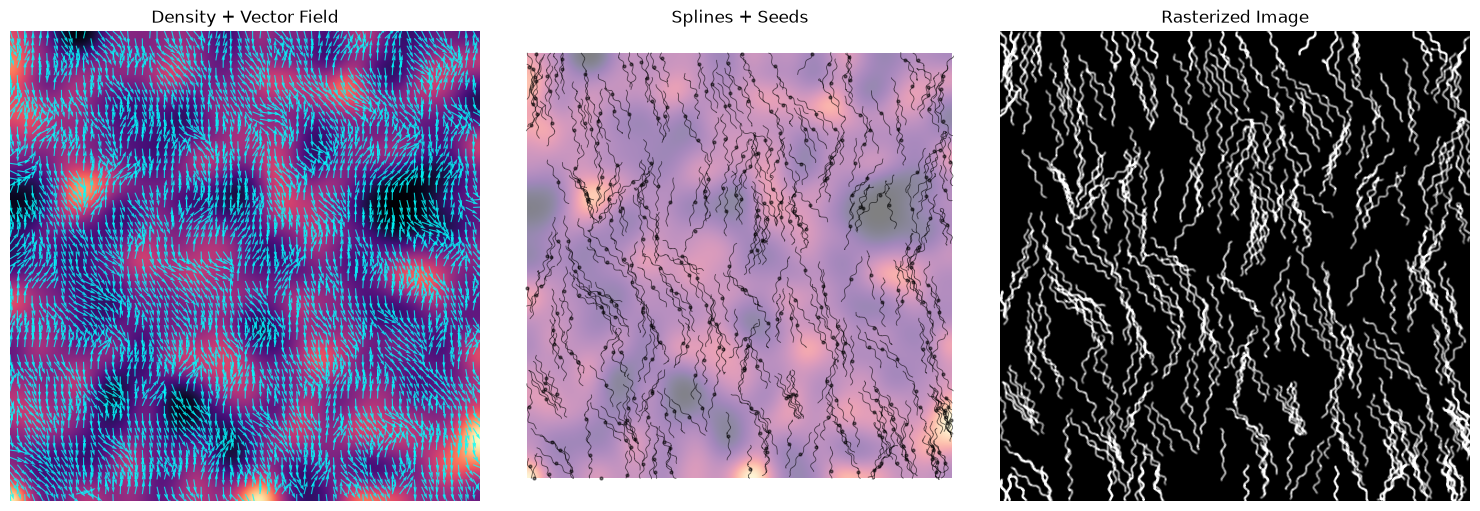

In [2]:
res = generate_synthetic_shg(
    seed=seed, 
    G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=400,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=0.5,
    show_plots=True,
    minimal=True,
    base_noise=30.0
)

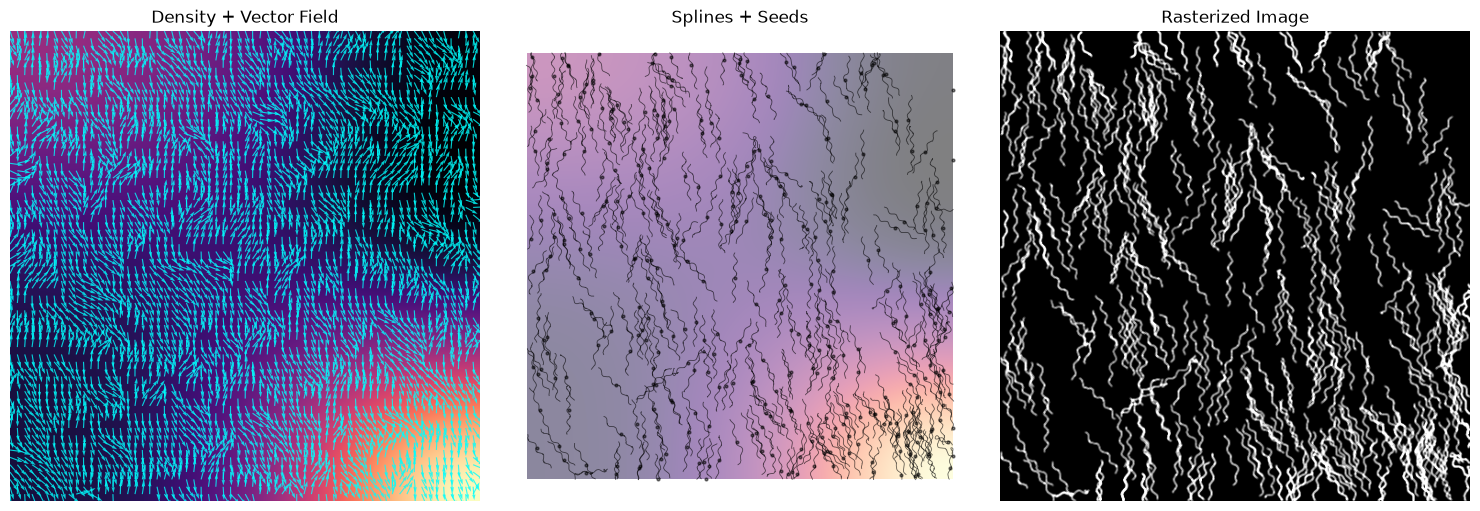

In [ ]:
res = generate_synthetic_shg(
    seed=seed, 
    G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=400,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=0.5,
    show_plots=True,
    minimal=True,
    base_noise=300.0
)

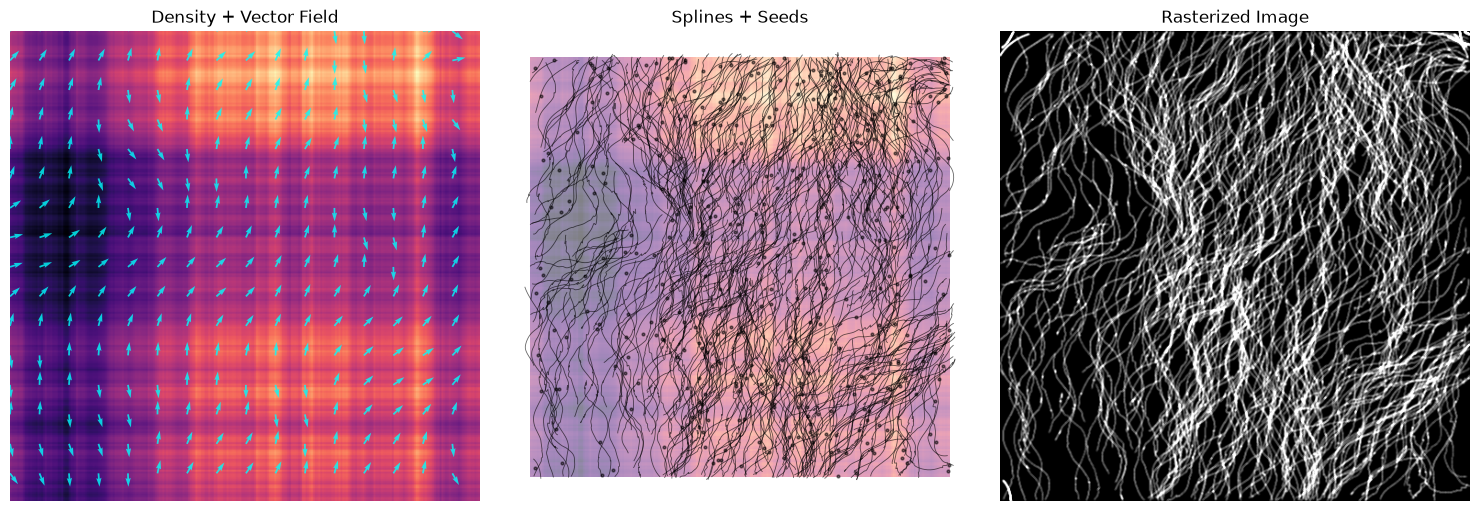

In [ ]:
res = generate_synthetic_shg(
    seed=seed, 
    resolution_factor = 4,
    G_align=0.3, G_density=0.7, G_curve=0, G_conn=0.9,
    L_align=0.4, L_density=0.4, L_conn=1, L_curve=0.6,
    spline_length=60, spline_num=400,
    wave_amplitude_px=6,      # bump for visibly wavier fibers
    wave_wavelength_px=30,    # None -> auto from fiber_width_px
    L_wave_freq=1,
    show_plots=True,
    minimal=True,
    base_noise=1000.0
)

# Testing generation pipeline for ML

In [ ]:
import base64, io, json, os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import streamlit as st
import streamlit.components.v1 as components
from PIL import Image

from typing import List, Tuple, Optional, Dict, Any

from typing import Optional

# from shg_backend import (
#     _well_weight_and_tangent, create_grid, fit_spline,
#     generate_custom_fields_from_canvas, generate_fiber,
#     make_fiber_aux_fields, make_global_orientation, make_wave_freq_field,
#     rasterize_splines, relax, sample_field_at_seeds,
#     sample_seeds_from_density, sinusoidal_fiber_offset,
# )

import sys
from pathlib import Path
import random
import h5py
from SyntheticGen import *


In [32]:
import random
from SyntheticGen import *

n_images = 1
seed = 10

random.seed(seed)

for n in range(n_images):
    G_align = round(random.uniform(0.005, 1.0), 2)
    G_density = round(random.uniform(0.005, 1.0), 2)
    G_curve = round(random.uniform(0, 1.0), 2)
    G_conn = round(random.uniform(0, 1.0), 2)

    L_align = round(random.uniform(0.005, 1.0), 2)
    L_density = round(random.uniform(0.005, 1.0), 2)
    L_curve = round(random.uniform(0, 1.0), 2)
    L_conn = round(random.uniform(0, 1.0), 2)

    spline_length = int(round(random.uniform(50, 500), 1))
    spline_num = int(round(random.uniform(100, 1000), 1))

    wave_amplitude_px = int(round(random.uniform(0, 10)))
    wave_wavelength_px = int(round(random.uniform(10, 70)))

    L_wave_freq = round(random.uniform(0, 1.0), 2)

    base_noise = int(round(random.uniform(30, 1000), 1))

    meta_data = [
        G_align, G_density, G_curve, G_conn,
        L_align, L_density, L_curve, L_conn, 
        spline_length, spline_num, 
        wave_amplitude_px, wave_wavelength_px, 
        L_wave_freq, 
        base_noise
    ]

    # res = generate_synthetic_shg(
    #     seed=seed, 
    #     G_align=G_align, G_density=G_density, G_curve=G_curve, G_conn=G_conn,
    #     L_align=L_align, L_density=L_density, L_conn=L_conn, L_curve=L_curve,
    #     spline_length=spline_length, spline_num=spline_num,
    #     wave_amplitude_px=wave_amplitude_px,      # bump for visibly wavier fibers
    #     wave_wavelength_px=wave_wavelength_px,    # None -> auto from fiber_width_px
    #     L_wave_freq=L_wave_freq,
    #     show_plots=False,
    #     minimal=True,
    #     base_noise=base_noise
    # )

    res['meta'] = meta_data

    save = f"{wave_amplitude_px}_{wave_wavelength_px}_{spline_length}_{spline_num}_{base_noise}"
    print(save)
    # with open("data.pkl", "wb") as f:
    #     pickle.dump(res, f)


2_67_284_395_73


In [34]:
f"synthetic_{save}.pkl"

'synthetic_2_67_284_395_73.pkl'

In [ ]:
    return {
        "Qx": Qx,
        "Qy": Qy,
        "D": D,
        "theta": theta,
        "seeds": seeds,
        "fibers": fibers,
        "splines": layers,
        "image": total_image,
        "wells": wells,
        "well_influence": influence,
        "aux_L_curve": aux_L_curve,
        "aux_L_conn": aux_L_conn,
        "aux_L_wave_freq": aux_L_wave_freq,
        "aux_susceptibility": aux_susceptibility,
        "opacity_table": opacity_table,
        "spline_length": spline_length,
    }

In [7]:
res['theta']

array([[-0.34771064, -0.34730071, -0.34648273, ..., -0.35727994,
        -0.35805289, -0.35844063],
       [-0.34760497, -0.34719505, -0.34637706, ..., -0.3568107 ,
        -0.35758172, -0.35796847],
       [-0.3473731 , -0.34696318, -0.34614514, ..., -0.35586563,
        -0.3566328 , -0.35701761],
       ...,
       [-0.30402498, -0.3041959 , -0.30451776, ...,  0.03241003,
         0.03384254,  0.03456194],
       [-0.3031136 , -0.30328422, -0.30360547, ...,  0.03409973,
         0.03553701,  0.03625881],
       [-0.30266619, -0.30283664, -0.30315757, ...,  0.03494071,
         0.03638038,  0.03710338]], shape=(1024, 1024))

In [18]:
print(f"{res['theta'].min()}")
print(f"{res['theta'].max()}")

-1.5707947082460254
1.5707959453104856


In [20]:
A = res['theta'].min()
B = res['theta'].max()

arr_norm = 2 * (res['theta'] - A) / (B - A) - 1

In [16]:
def normalize(x):
    return 2 * (x - A) / (B - A) - 1

In [14]:
print(f"{res['D'].min()}")
print(f"{res['D'].max()}")


0.49432356072592165
0.9694785509155547
